In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/churn_processed.csv")
df.head()

,seniorcitizen,tenure,monthlycharges,gender_male,dependents_yes,phoneservice_yes,multiplelines_yes,internetservice_fiber optic,contract_one year,contract_two year,churn
0,0,1,25,0,0,0,0,0,0,0,1
1,0,41,25,1,0,1,0,0,1,0,0
2,0,52,19,0,1,1,0,0,0,0,0
3,0,1,76,0,0,1,0,0,1,0,1
4,0,67,51,1,0,1,0,1,0,0,0


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (7043, 11)

Columns:
['seniorcitizen', 'tenure', 'monthlycharges', 'gender_male', 'dependents_yes', 'phoneservice_yes', 'multiplelines_yes', 'internetservice_fiber optic', 'contract_one year', 'contract_two year', 'churn']


In [4]:
df["churn"].value_counts()

churn
0    5174
1    1869
Name: count, dtype: int64

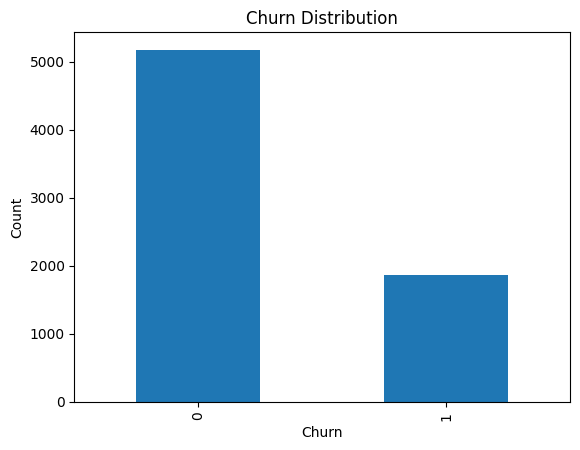

In [5]:
df["churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [6]:
df.groupby("churn")[["tenure", "monthlycharges", "seniorcitizen"]].mean()

,tenure,monthlycharges,seniorcitizen
churn,,,
0,37.569965,61.265752,0.128721
1,17.979133,74.428571,0.254682


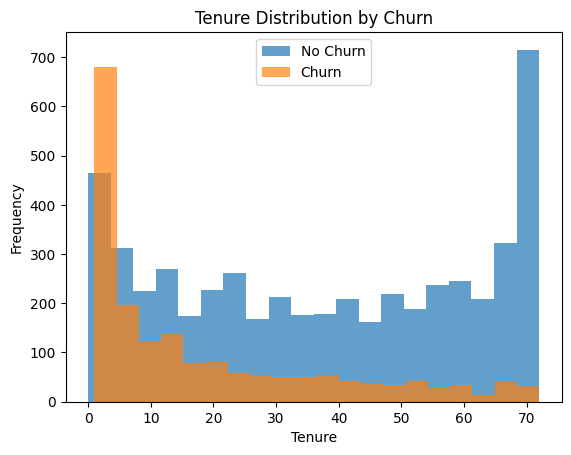

In [7]:
plt.hist(df[df["churn"] == 0]["tenure"], bins=20, alpha=0.7, label="No Churn")
plt.hist(df[df["churn"] == 1]["tenure"], bins=20, alpha=0.7, label="Churn")
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure")
plt.ylabel("Frequency")
plt.legend()
plt.show()

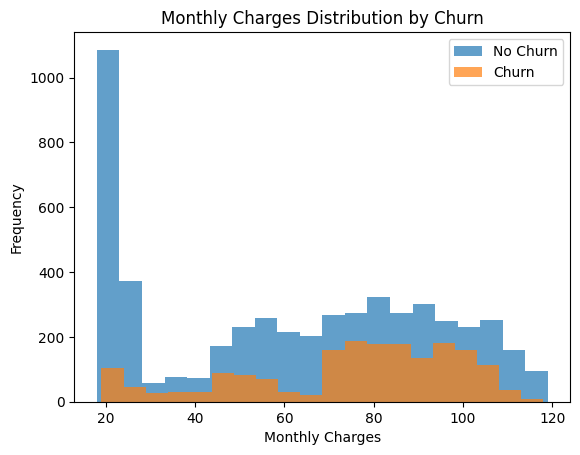

In [8]:
plt.hist(df[df["churn"] == 0]["monthlycharges"], bins=20, alpha=0.7, label="No Churn")
plt.hist(df[df["churn"] == 1]["monthlycharges"], bins=20, alpha=0.7, label="Churn")
plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [9]:
df.groupby("seniorcitizen")["churn"].mean()

seniorcitizen
0    0.236062
1    0.416813
Name: churn, dtype: float64

In [10]:
def contract_type(row):
    if row["contract_one year"] == 1:
        return "One year"
    elif row["contract_two year"] == 1:
        return "Two year"
    else:
        return "Month-to-month"

df["contract_type"] = df.apply(contract_type, axis=1)
df["contract_type"].value_counts()

contract_type
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [11]:
df.groupby("contract_type")["churn"].mean().sort_values(ascending=False)

contract_type
Month-to-month    0.273290
One year          0.257977
Two year          0.253687
Name: churn, dtype: float64

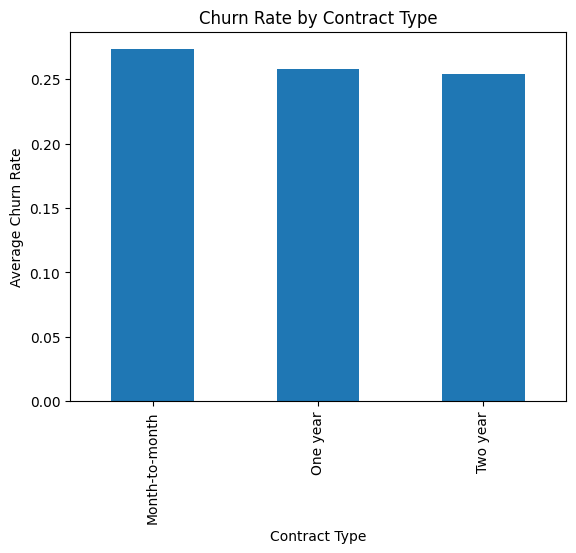

In [12]:
df.groupby("contract_type")["churn"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Average Churn Rate")
plt.show()

In [13]:
def internet_type(row):
    if row["internetservice_fiber optic"] == 1:
        return "Fiber optic"
    else:
        return "DSL"

df["internet_type"] = df.apply(internet_type, axis=1)
df["internet_type"].value_counts()

internet_type
DSL            3947
Fiber optic    3096
Name: count, dtype: int64

In [14]:
df.groupby("internet_type")["churn"].mean()

internet_type
DSL            0.274132
Fiber optic    0.254199
Name: churn, dtype: float64

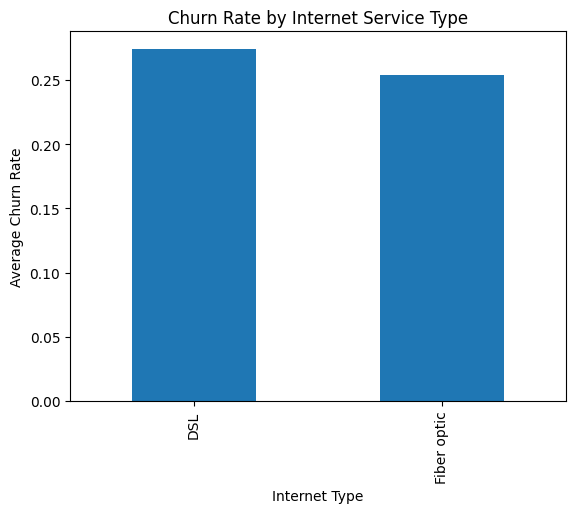

In [15]:
df.groupby("internet_type")["churn"].mean().plot(kind="bar")
plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Type")
plt.ylabel("Average Churn Rate")
plt.show()

In [16]:
df.groupby("gender_male")["churn"].mean()

gender_male
0    0.269209
1    0.261603
Name: churn, dtype: float64

In [17]:
corr = df.corr(numeric_only=True)
corr["churn"].sort_values(ascending=False)

churn                          1.000000
monthlycharges                 0.193150
seniorcitizen                  0.150889
phoneservice_yes               0.011942
multiplelines_yes             -0.000270
contract_one year             -0.008611
gender_male                   -0.008612
contract_two year             -0.014896
internetservice_fiber optic   -0.022408
dependents_yes                -0.164221
tenure                        -0.352229
Name: churn, dtype: float64